# Etape de modilisation:



In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')

##librairie DEEP LEARNING
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Activation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **MODELE CNN:**

#### **`1. Modele pour grid:`**

Dans cette partie, nous alons faire un modele pour la categorie grdi afin de voir si notre approche permet d'obtenir un modele perfermant qui arrive à classer la classe des anomalies avec une bonne precision et un bon rappel aussi.

###### **`Segmentation:`**

Pour chaque catégorie du jeu de données MVTec, une analyse visuelle a permis d’identifier la nature dominante des défauts. Les défauts chromatiques ont été traités par une segmentation basée sur la couleur, tandis que les défauts structurels ont été traités par une segmentation basée sur les contours. Lorsque les défauts sont internes ou purement texturels, aucune segmentation n’a été appliquée.

| Catégorie MVTec | Type de catégorie | Type dominant de défaut         | Segmentation recommandée |
| --------------- | ----------------- | ------------------------------- | ------------------------ |
| **carpet**      | Texture           | Texture / couleur diffuse       | **Couleur**              |
| **grid**        | Texture           | Structure (lignes cassées)      | **Contours**             |
| **leather**     | Texture           | Couleur / texture               | **Couleur**              |
| **tile**        | Texture           | Couleur / motif                 | **Couleur**              |
| **wood**        | Texture           | Couleur / texture               | **Couleur**              |
| **bottle**      | Objet             | Texture interne / contamination | **Aucune**               |
| **cable**       | Objet             | Structure / coupure             | **Contours**             |
| **capsule**     | Objet             | Couleur / texture               | **Couleur**              |
| **hazelnut**    | Objet             | Couleur (zones brunies)         | **Couleur**              |
| **metal_nut**   | Objet             | Forme / géométrie               | **Contours**             |
| **pill**        | Objet             | Couleur / surface               | **Couleur**              |
| **screw**       | Objet             | Forme / orientation             | **Contours**             |
| **toothbrush**  | Objet             | Forme / structure               | **Contours**             |
| **transistor**  | Objet             | Structure / composants          | **Contours**             |
| **zipper**      | Objet             | Structure (dents manquantes)    | **Contours**             |


Cette fonction réalise une segmentation par couleur.
Son but est de conserver uniquement les zones colorées de l’image et de supprimer les zones peu colorées (blanc, gris, noir, ombres).


La segmentation repose sur la saturation des couleurs :

Une couleur “forte” → saturation élevée

Une couleur “fade”, gris ou blanc → saturation faible

On utilise donc la composante S (Saturation) pour décider quels pixels garder.

In [ ]:
def segment_color_simple(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    mask = (s > 30).astype("uint8") * 255
    return cv2.bitwise_and(img, img, mask=mask)


Cette fonction réalise une segmentation basée sur les contours.
Son but est de :

* Détecter l’objet principal dans l’image
* Découper l’image pour ne garder que la zone de cet objet

In [ ]:
def segment_contour_simple(img):
    # Si l'image est déjà en niveaux de gris
    if img.ndim == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    return img[y:y+h, x:x+w]

In [ ]:
SEGMENTATION_BY_CATEGORY = {
    "grid": "none",
    "cable": "contour",
    "screw": "contour",
    "zipper": "contour",
    "metal_nut": "contour",

    "wood": "color",
    "leather": "color",
    "tile": "color",
    "carpet": "color",
    "pill": "color",
    "hazelnut": "color",
    "capsule": "color",

    "bottle": "none",
}


In [ ]:
##choisir la segmentation à appliquer

def apply_segmentation(img, category):
    mode = SEGMENTATION_BY_CATEGORY.get(category, "none")

    if mode == "contour":
        return segment_contour_simple(img)

    elif mode == "color":
        return segment_color_simple(img)

    else:  # "none"
        return img


**Justification des choix de segmentation par categorie:**

| Catégorie      | Type    | Segmentation choisie | Pourquoi ce choix est pertinent                                                                                                                                                                |
| -------------- | ------- | -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **carpet**     | Texture | Couleur              | Les défauts apparaissent comme des variations chromatiques et de texture réparties sur la surface. La segmentation couleur permet d’isoler les zones anormales et de réduire le bruit du fond. |
| **grid**       | Texture | Contours             | Les défauts se traduisent par des ruptures de lignes et des discontinuités structurelles. La segmentation par contours met en évidence ces anomalies géométriques.                             |
| **leather**    | Texture | Couleur              | Les défauts correspondent principalement à des décolorations et des irrégularités de surface visibles par la couleur.                                                                          |
| **tile**       | Texture | Couleur              | Les anomalies modifient les motifs et la teinte des carreaux. La segmentation couleur permet de détecter ces différences chromatiques.                                                         |
| **wood**       | Texture | Couleur              | Les défauts (taches, brûlures) sont principalement de nature chromatique et se distinguent par la couleur.                                                                                     |
| **bottle**     | Objet   | Aucune               | L’objet est centré sur fond uniforme et les défauts sont internes. Une segmentation pourrait supprimer des informations utiles.                                                                |
| **cable**      | Objet   | Contours             | Les défauts affectent la structure du câble (coupures, déformations). La segmentation par contours permet d’isoler la forme.                                                                   |
| **capsule**    | Objet   | Couleur              | Les défauts se manifestent par des variations de couleur et de texture sur la surface.                                                                                                         |
| **hazelnut**   | Objet   | Couleur              | Les anomalies sont visibles sous forme de zones brunies ou décolorées, donc chromatiques.                                                                                                      |
| **metal_nut**  | Objet   | Contours             | Les défauts modifient la géométrie et les arêtes de l’objet métallique. Les contours sont discriminants.                                                                                       |
| **pill**       | Objet   | Couleur              | Les anomalies correspondent à des différences de teinte et d’aspect de surface.                                                                                                                |
| **screw**      | Objet   | Contours             | Les défauts entraînent des déformations de la vis, visibles au niveau de la forme et des bords.                                                                                                |
| **toothbrush** | Objet   | Contours             | Les anomalies affectent la structure et l’alignement de l’objet.                                                                                                                               |
| **transistor** | Objet   | Contours             | Les défauts sont liés à la disposition et à la forme des composants.                                                                                                                           |
| **zipper**     | Objet   | Contours             | Les anomalies se manifestent par des dents manquantes ou mal alignées, donc structurelles.                                                                                                     |


###### **`Appliquer une extraction de feature :`**

La règle de base (débutant)

Pour un type d’objet, on choisit l’extraction de features selon la propriété la plus stable et la plus discriminante :

* Couleur / teinte dominante → extract_color_features (histogrammes HSV)

* Texture / motif répétitif → extract_lbp_features (LBP)

* Forme / bords / structure → extract_hog_features (HOG)

L’objectif est d’avoir un vecteur qui sépare bien “normal” vs “anormal” pour cet objet, sans être trop sensible aux variations inutiles (luminosité, petits décalages, etc.).

1) Pourquoi choisir les features couleur (HSV histogrammes) ?
Quand c’est pertinent

Matériaux avec couleur/teinte caractéristique : wood, leather, tile, carpet, pill, hazelnut, capsule…

Quand les anomalies changent souvent :

* la teinte (H)

* la saturation (S) (tache, décoloration, zone “fade”)

Pourquoi HSV (H & S)

* H capture “quelle couleur”

* S capture “à quel point c’est coloré”

* Ça évite de trop dépendre de la luminosité (V) → plus robuste.

En résumé : si l’objet se reconnaît surtout par sa couleur / matière colorée, l’histogramme HSV est un bon choix.

In [ ]:
def extract_color_features(img, bins=16):
    """
    Histogrammes couleur simples (HSV).
    Retourne un vecteur 1D normalisé.
    """
    # Si image en gris = pas de couleur
    if img.ndim == 2:
        return np.zeros(bins * 2, dtype=np.float32)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256])

    hist = np.concatenate([hist_h, hist_s]).flatten()
    hist = hist / (hist.sum() + 1e-8)

    return hist.astype(np.float32)


2) Pourquoi choisir les features texture (LBP) ?
Quand c’est pertinent

Surfaces avec motifs et micro-textures :

* carpet, tile, leather, wood (souvent)

Anomalies typiques :

* rayures fines

* trous

* zones rugueuses / lisses anormales

* changements locaux de texture

Pourquoi LBP

LBP compare chaque pixel à ses voisins → il décrit des patterns locaux (grain, rugosité) et fait un histogramme global.

En résumé : si le “grain” ou le motif du matériau est l’information la plus importante, LBP est souvent plus discriminant que la couleur.

In [ ]:
def extract_lbp_features(img):
    """
    LBP simple (8 voisins) + histogramme.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = gray.astype(np.uint8)
    h, w = gray.shape

    lbp = np.zeros((h, w), dtype=np.uint8)

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            center = gray[y, x]
            code = 0
            code |= (gray[y-1, x-1] >= center) << 7
            code |= (gray[y-1, x  ] >= center) << 6
            code |= (gray[y-1, x+1] >= center) << 5
            code |= (gray[y,   x+1] >= center) << 4
            code |= (gray[y+1, x+1] >= center) << 3
            code |= (gray[y+1, x  ] >= center) << 2
            code |= (gray[y+1, x-1] >= center) << 1
            code |= (gray[y,   x-1] >= center) << 0
            lbp[y, x] = code

    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + 1e-8)

    return hist


3) Pourquoi choisir les features forme/bords (HOG) ?
Quand c’est pertinent

Objets où la géométrie et les bords dominent :

screw, cable, zipper, grid, metal_nut…

Anomalies typiques :

* déformation de forme

* pièce manquante / cassée

* mauvais alignement / partie tordue

* contour anormal

Pourquoi HOG

HOG résume les orientations de gradients (les directions des bords) sur des cellules → excellent pour décrire structure + forme, même si la couleur change peu.

En résumé : si l’objet est surtout “une forme” avec des contours nets, HOG est généralement plus adapté que la couleur.

In [ ]:
def extract_hog_features(img):
    """
    HOG simple avec OpenCV.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = cv2.resize(gray, (128, 128))

    hog = cv2.HOGDescriptor(
        _winSize=(128, 128),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )

    features = hog.compute(gray)
    return features.flatten().astype(np.float32)


In [ ]:
def extract_features(img, category):
    features = []

    if category in ["wood", "leather", "tile", "carpet", "pill", "hazelnut", "capsule"]:
        features.append(extract_color_features(img))
        features.append(extract_lbp_features(img))

    elif category in ["grid", "cable", "screw", "zipper", "metal_nut",
                      "toothbrush", "transistor"]:
        features.append(extract_hog_features(img))

    elif category == "bottle":
        features.append(extract_lbp_features(img))
        features.append(extract_hog_features(img))

    else:
        features.append(extract_lbp_features(img))

    return np.concatenate(features)


Dans le tableau ci-dessous nous avons detaillé et justifier les choix des extraction de feature utilisé pour chaque categorie:

| Catégorie      | Type (Texture / Objet) | Type dominant de défaut         | Segmentation choisie | Features recommandées | Justification                                               |
| -------------- | ---------------------- | ------------------------------- | -------------------- | --------------------- | ----------------------------------------------------------- |
| **carpet**     | Texture                | Texture / couleur diffuse       | Couleur              | Couleur + LBP         | Défauts visibles par variations chromatiques et texturelles |
| **grid**       | Texture                | Structure (lignes cassées)      | Contours             | HOG                   | Les anomalies sont des ruptures géométriques                |
| **leather**    | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Défauts visibles par décoloration et texture                |
| **tile**       | Texture                | Motif / couleur                 | Couleur              | Couleur + LBP         | Changements de motif et de teinte                           |
| **wood**       | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Taches et brûlures chromatiques                             |
| **bottle**     | Objet                  | Texture interne / contamination | Aucune               | LBP + HOG             | Défauts internes détectables par texture                    |
| **cable**      | Objet                  | Structure / coupure             | Contours             | HOG                   | Défauts de forme et de continuité                           |
| **capsule**    | Objet                  | Couleur / texture               | Couleur              | Couleur + LBP         | Variations chromatiques de surface                          |
| **hazelnut**   | Objet                  | Couleur (zones brunies)         | Couleur              | Couleur + LBP         | Anomalies visibles par la teinte                            |
| **metal_nut**  | Objet                  | Géométrie / arêtes              | Contours             | HOG                   | Défauts affectant la forme                                  |
| **pill**       | Objet                  | Couleur / surface               | Couleur              | Couleur + LBP         | Défauts chromatiques et texturels                           |
| **screw**      | Objet                  | Forme / orientation             | Contours             | HOG                   | Déformations de la vis                                      |
| **toothbrush** | Objet                  | Structure                       | Contours             | HOG                   | Défauts géométriques                                        |
| **transistor** | Objet                  | Structure / composants          | Contours             | HOG                   | Disposition anormale des composants                         |
| **zipper**     | Objet                  | Structure (dents manquantes)    | Contours             | HOG                   | Ruptures dans la structure des dents                        |


###### **`Appliquer les preprocissing et création de X et y à partir des données de train et test :`**

In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category):

    """ fonction qui permet de regrouper


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {category} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)



      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))


      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))

      #EXTRACTION DE FEATURES
      #feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





###### **`Creation de X et y  :`**

In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
train_path= glob(path)

X_train_grid= []
y_train_grid=[]
for category_path in train_path:
  category = os.path.basename(os.path.dirname(os.path.dirname(category_path)))
  X_cate= Dataset_supervise(category_path,category)
  y_anom = np.zeros(len(X_cate), dtype=np.int64)
  X_train_grid.append(X_cate)
  y_train_grid.append(y_anom)

X_train_grid= np.concatenate(X_train_grid, axis=0)
y_train_grid= np.concatenate(y_train_grid, axis=0)
print("X_train_good:", X_train_grid.shape)
print("y_train_good:", y_train_grid.shape, "labels:", np.unique(y_train_grid))

Nombre d'images trouvées dans grid : 264
X_train_good: (264, 256, 256)
y_train_good: (264,) labels: [0]


In [ ]:
## liste pour stocker X_test et y_test
X_test_grid= []
y_test_grid= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid.append(X_good)
        y_test_grid.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid.append(X_anom)
            y_test_grid.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid = np.concatenate(X_test_grid, axis=0)
y_test_grid = np.concatenate(y_test_grid, axis=0)

print(X_test_grid.shape, y_test_grid.shape)


Nombre d'images trouvées dans grid : 21
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
(78, 256, 256) (78,)


In [ ]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_grid, X_test_grid], axis=0)
y = np.concatenate([y_train_grid, y_test_grid], axis=0)

print(X.shape, y.shape)


(342, 256, 256) (342,)


##### **`Pour commencé, nous avons utilisé le Train et test de grid uniquement avec de la segmentation sans augmentation de la données test avec anomalie:`**

In [ ]:
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [ ]:
X_train.shape


(273, 256, 256)

In [ ]:
import numpy as np
print(np.sqrt(X_train.shape[1]))

16.0


In [ ]:
# Entrée
inputs = Input(shape=(256, 256, 1), name="input_image")

# conv1
x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2, 2))(x)

#conv 2
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Bloc conv 3
x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Applatir pour les utiliser dans dense
x = Flatten()(x)
# Couche Dense 1
x = Dense(128, activation="relu")(x)

# Couche Dense 2
outputs = Dense(1, activation="sigmoid", name="output")(x)

# Modèle
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,145 (64.35 MB)

 Trainable params: 16,870,145 (64.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",  metrics=["accuracy"])

In [ ]:
#### entrainnement du modele  en utilisant epochs=10, batch_size=32 et on laisse 20% pour les données de validation

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)



Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.6072 - loss: 1.0947 - val_accuracy: 0.8545 - val_loss: 0.4255
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.8327 - loss: 0.4814 - val_accuracy: 0.8545 - val_loss: 0.5373
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7951 - loss: 0.5394 - val_accuracy: 0.8545 - val_loss: 0.4333
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 5s/step - accuracy: 0.8448 - loss: 0.4396 - val_accuracy: 0.8545 - val_loss: 0.4700
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8404 - loss: 0.4856 - val_accuracy: 0.8545 - val_loss: 0.4227
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.8198 - loss: 0.4807 - val_accuracy: 0.8545 - val_loss: 0.4299
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8323 - loss: 0.4624 - val_accuracy: 0.8545 - val_loss: 0.4272
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.8333 - loss: 0.4600 - val_accuracy: 0.8545 - val_loss: 0.4285
Epoch 9/

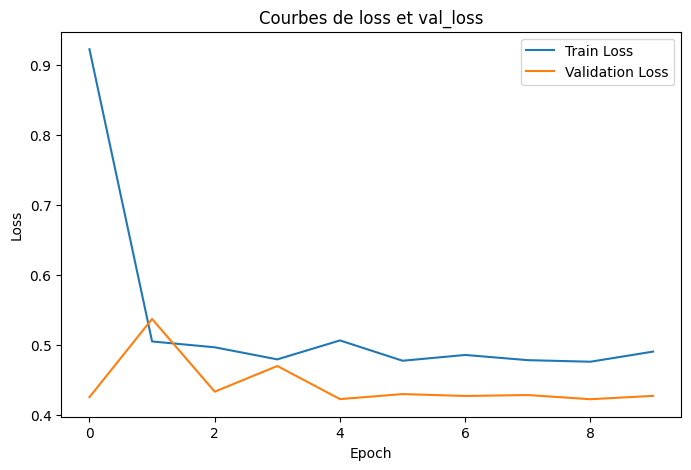

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
##faire les prediction avec X_test:
y_proba = model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.5).astype(int)       # classes 0/1

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 734ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

Accuracy : 0.86
Precision: 0.00
Recall:  0.00
F1-score: 0.00
Confusion Matrix:
 [[59  0]
 [10  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##### **`pour continuer, nous avons utilisé le Train et test de grid uniquement avec de la segmentation et augmentation de la données test  anomalie:`**

In [ ]:
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [ ]:
# Entrée
inputs = Input(shape=(256, 256, 1), name="input_image")

# conv1
x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2, 2))(x)

#conv 2
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Bloc conv 3
x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Applatir pour les utiliser dans dense
x = Flatten()(x)
# Couche Dense 1
x = Dense(128, activation="relu")(x)
# Couche Dense 2
x = Dense(64, activation="relu")(x)
# Couche Dense 3
x = Dense(32, activation="relu")(x)
# Couche Dense 4
x = Dense(16, activation="relu")(x)
# Couche Dense 5
x = Dense(8, activation="relu")(x)
# Couche Dense 6
x = Dense(4, activation="relu")(x)

# Couche Dense 2
outputs = Dense(2, activation="sigmoid", name="output")(x)

# Modèle
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,881,062 (64.40 MB)

 Trainable params: 16,881,062 (64.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",  metrics=["accuracy"])

In [ ]:
#### entrainnement du modele  en utilisant epochs=10, batch_size=32 et on laisse 20% pour les données de validation

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)



Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.5714 - loss: 0.6929 - val_accuracy: 0.5636 - val_loss: 0.6917
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.5868 - loss: 0.6906 - val_accuracy: 0.5636 - val_loss: 0.6906
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.5941 - loss: 0.6888 - val_accuracy: 0.5636 - val_loss: 0.6896
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.5884 - loss: 0.6875 - val_accuracy: 0.5636 - val_loss: 0.6887
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.5937 - loss: 0.6858 - val_accuracy: 0.5636 - val_loss: 0.6879
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.6148 - loss: 0.6822 - val_accuracy: 0.5636 - val_loss: 0.6872
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.6013 - loss: 0.6822 - val_accuracy: 0.5636 - val_loss: 0.6867
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.5999 - loss: 0.6813 - val_accuracy: 0.5636 - val_loss:

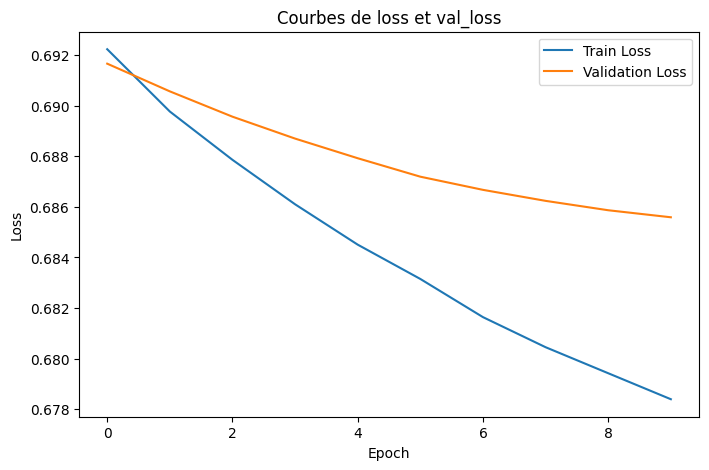

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
##faire les prediction avec X_test:
y_proba = model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.5).astype(int)       # classes 0/1

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 842ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

ValueError: Found input variables with inconsistent numbers of samples: [137, 274]

In [ ]:
##faire les prediction avec X_test:
y_proba = model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.65).astype(int)       # classes 0/1

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 852ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

#### **Ici on augmente la données sans anomalie et avec anoamlie pour avoir des classe equilibré:`**

###### **`Appliquer les preprocissing et création de X et y à partir des données de train et test :`**

###### **`Augmentation des données selon la categorie et selon normal ou anormale: augmentation biaisée`**

In [ ]:
def augment_normal_texture(img):
    out = img.copy()
    h, w = out.shape[:2]

    # rotation très légère
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-5, 5)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        out = cv2.warpAffine(
            out, M, (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # translation très légère
    if np.random.rand() < 0.5:
        tx = np.random.uniform(-0.03*w, 0.03*w)
        ty = np.random.uniform(-0.03*h, 0.03*h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(
            out, M, (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # bruit capteur très léger
    if np.random.rand() < 0.3:
        out_f = out.astype(np.float32) / 255.0
        noise = np.random.normal(0, 0.01, out_f.shape)
        out = np.clip(out_f + noise, 0, 1)
        out = (out * 255).astype(np.uint8)

    return out


In [ ]:
def augment_normal_object(img):
    out = img.copy()
    h, w = out.shape[:2]

    # rotation légère
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-8, 8)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        out = cv2.warpAffine(
            out, M, (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # translation légère
    if np.random.rand() < 0.5:
        tx = np.random.uniform(-0.05*w, 0.05*w)
        ty = np.random.uniform(-0.05*h, 0.05*h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(
            out, M, (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # bruit léger
    if np.random.rand() < 0.3:
        out_f = out.astype(np.float32) / 255.0
        noise = np.random.normal(0, 0.015, out_f.shape)
        out = np.clip(out_f + noise, 0, 1)
        out = (out * 255).astype(np.uint8)

    # variation de luminosité (OK pour objets)
    if np.random.rand() < 0.4:
        factor = np.random.uniform(0.9, 1.1)
        out = np.clip(out.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    return out


In [ ]:
def augment_anomaly_object(img):
    out = img.copy()
    h, w = out.shape[:2]

    # rayure
    x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
    x2, y2 = np.random.randint(0, w), np.random.randint(0, h)
    thickness = np.random.randint(2, 5)

    scratch = np.zeros((h, w), np.uint8)
    cv2.line(scratch, (x1, y1), (x2, y2), 255, thickness)
    scratch = cv2.GaussianBlur(scratch, (5, 5), 0)

    out_f = out.astype(np.float32) / 255.0
    out_f = np.clip(out_f - 0.6 * (scratch/255.0), 0, 1)
    out = (out_f * 255).astype(np.uint8)

    return out


In [ ]:
def augment_anomaly_texture(img):
    out = img.copy()
    h, w = out.shape[:2]

    # tache locale
    cx, cy = np.random.randint(w//8, 7*w//8), np.random.randint(h//8, 7*h//8)
    radius = np.random.randint(8, 25)
    intensity = np.random.uniform(0.4, 0.8)

    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (cx, cy), radius, 255, -1)
    mask = cv2.GaussianBlur(mask, (0, 0), radius/2)

    out_f = out.astype(np.float32) / 255.0
    out_f = out_f * (1 - intensity * (mask/255.0))
    out = np.clip(out_f * 255, 0, 255).astype(np.uint8)

    return out


In [ ]:
TEXTURES = {"grid", "wood", "tile", "carpet", "leather"}
OBJECTS  = {"bottle", "cable", "screw", "zipper", "metal_nut", "capsule", "hazelnut", "pill"}

def augment_normal(img, category):
    if category in TEXTURES:
        # géométrique + bruit léger
        return augment_normal_texture(img)
    else:
        # géométrique + photométrique légère
        return augment_normal_object(img)

def augment_anomaly(img, category):
    if category in TEXTURES:
        return augment_anomaly_texture(img)
    else:
        return augment_anomaly_object(img)


###### **`Augmentation des données avec rotation et transalation : `**

In [ ]:
def augment_rotate_translate(img):
    """
    Augmentation légère : rotation + translation
    img : image numpy (H, W) ou (H, W, C)
    """
    out = img.copy()
    h, w = out.shape[:2]

    # Rotation légère (±5°)
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-5, 5)
        M_rot = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        out = cv2.warpAffine(
            out,
            M_rot,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # 2) Translation légère (±3 %)
    if np.random.rand() < 0.5:
        tx = np.random.uniform(-0.03 * w, 0.03 * w)
        ty = np.random.uniform(-0.03 * h, 0.03 * h)
        M_trans = np.float32([[1, 0, tx],
                              [0, 1, ty]])
        out = cv2.warpAffine(
            out,
            M_trans,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

    return out


###### **`Appliquer les preprocessing`**

In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category, color_mode="rgb"):

    """ Dans cette fonction on ajoute l'augmentation de la données des test :
          """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {os.path.join(path, category)} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))

      #convertir en RGB (si tu préfères travailler en RGB)
      if color_mode.lower() == "rgb":
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


      img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





###### **`Affichage l'image avant et aprés segmentation:`**

In [ ]:
diff = np.abs(img.astype(float) - img_aug.astype(float))
print("Diff moyenne:", diff.mean())
print("Diff max:", diff.max())


plt.imshow(diff, cmap="hot")
plt.title("Carte des différences")
plt.colorbar()
plt.show()


NameError: name 'img' is not defined

In [ ]:
thr = 20
mask = (diff >= thr).astype(np.uint8)

ratio = mask.mean() * 100
print(f"Pixels modifiés (>= {thr}) : {ratio:.2f}%")

plt.figure(figsize=(6,5))
plt.imshow(mask, cmap="gray")
plt.title(f"Masque des changements (>= {thr}) — {ratio:.2f}% pixels")
plt.axis("off")
plt.show()


NameError: name 'diff' is not defined

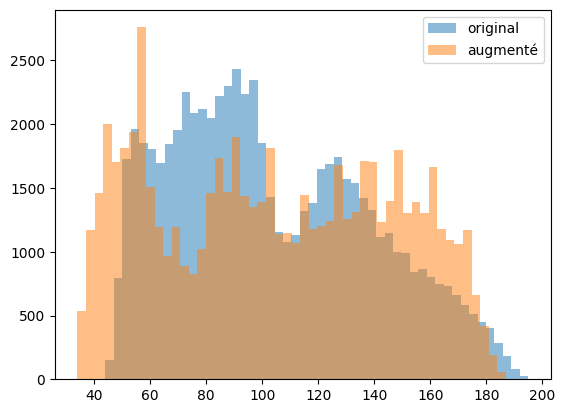

In [ ]:
plt.hist(img.ravel(), bins=50, alpha=0.5, label="original")

plt.hist(img_aug.ravel(), bins=50, alpha=0.5, label="augmenté")
plt.legend()
plt.show()


###### **`Creation de X et y engendre fuite de données ( methode abondonnées :`**

In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
train_path= glob(path)

X_train_grid_aug= []
y_train_grid_aug=[]
for category_path in train_path:
  category = os.path.basename(os.path.dirname(os.path.dirname(category_path)))
  X_cate= Dataset_supervise(category_path,category, do_augment=True, k=3)
  y_anom = np.zeros(len(X_cate), dtype=np.int64)
  X_train_grid_aug.append(X_cate)
  y_train_grid_aug.append(y_anom)

X_train_grid_aug= np.concatenate(X_train_grid_aug, axis=0)
y_train_grid_aug= np.concatenate(y_train_grid_aug, axis=0)
print("X_train_good:", X_train_grid_aug.shape)
print("y_train_good:", y_train_grid_aug.shape, "labels:", np.unique(y_train_grid))

Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good/grid : 264
X_train_good: (1056, 256, 256)
y_train_good: (1056,) labels: [0]


In [ ]:
print(Counter(y_train_grid_aug))

Counter({np.int64(0): 1056})


In [ ]:
## liste pour stocker X_test et y_test
X_test_grid_aug= []
y_test_grid_aug= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer le chemin
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=False, k=0)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid_aug.append(X_good)
        y_test_grid_aug.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chaque piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=True, k=12)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid_aug.append(X_anom)
            y_test_grid_aug.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid_aug = np.concatenate(X_test_grid_aug, axis=0)
y_test_grid_aug = np.concatenate(y_test_grid_aug, axis=0)

print(X_test_grid_aug.shape, y_test_grid_aug.shape)


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 11
(762, 256, 256) (762,)


In [ ]:
print(Counter(y_test_grid_aug))

Counter({np.int64(1): 741, np.int64(0): 21})


###### **`création de dossiers d'entrainnement et de test avec 20% de dossier test par rapport au donniers total:`**

In [ ]:
import os, random, shutil


base_dir = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid"
test_dir = os.path.join(base_dir, "test")
out_dir  = os.path.join(base_dir, "train", "anomaly_from_test")

random.seed(42)

# récupérer toutes les images anomalies (tous défauts confondus)
candidates = []
for defect in os.listdir(test_dir):
    if defect == "good":
        continue
    defect_dir = os.path.join(test_dir, defect)
    if not os.path.isdir(defect_dir):
        continue
    for p in glob(os.path.join(defect_dir, "*.*")):
        candidates.append((p, defect))

print("Total anomalies candidates:", len(candidates))

n_take = 30
n_take = min(n_take, len(candidates))
chosen = random.sample(candidates, n_take)

# déplacer
for p, defect in chosen:
    dest_defect_dir = os.path.join(out_dir, defect)
    os.makedirs(dest_defect_dir, exist_ok=True)
    shutil.move(p, os.path.join(dest_defect_dir, os.path.basename(p)))

print(f"Déplacé {n_take} images vers {out_dir}")
print("Elles ne sont plus dans test/")


Total anomalies candidates: 57
Déplacé 30 images vers /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test
Elles ne sont plus dans test/


In [ ]:
#GOOD (label 0)
path_good = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
good_paths = [path_good]

X_train_list, y_train_list = [], []

for category_path in good_paths:
    category = "grid"
    X_good = Dataset_supervise(category_path, category, do_augment=True, k=3)
    y_good = np.zeros(len(X_good), dtype=np.int64)
    X_train_list.append(X_good)
    y_train_list.append(y_good)

#ANOMALIES prélevées du test (label 1)
path_anom_train = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test"
anom_defect_dirs = [d for d in glob(os.path.join(path_anom_train, "*")) if os.path.isdir(d)]

for defect_dir in anom_defect_dirs:
    category = "grid"
    X_anom = Dataset_supervise(defect_dir, category, do_augment=True, k=30)
    y_anom = np.ones(len(X_anom), dtype=np.int64)
    X_train_list.append(X_anom)
    y_train_list.append(y_anom)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape, np.unique(y_train, return_counts=True))


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good/grid : 264
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/thread/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/bent/grid : 7
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/metal_contamination/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/ano

In [ ]:
## liste pour stocker X_test et y_test
X_test_grid_aug= []
y_test_grid_aug= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer le chemin
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=True, k=5)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid_aug.append(X_good)
        y_test_grid_aug.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chaque piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=True, k=9)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid_aug.append(X_anom)
            y_test_grid_aug.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test = np.concatenate(X_test_grid_aug, axis=0)
y_test= np.concatenate(y_test_grid_aug, axis=0)

print(X_test.shape, y_test.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape, np.unique(y_test, return_counts=True))

Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 5
(396, 256, 256, 3) (396,)
X_test: (396, 256, 256, 3)
y_test: (396,) 

#### **`Spliter et instancier le modele CNN:`**

Je ne vais pas utiliser split ici mais construire mes train et test seule :

In [ ]:
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

## X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

##normalisation
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

## reshape pour ajouter le canal
X_train = X_train.reshape(-1, 256, 256, 1)
X_test  = X_test.reshape(-1, 256, 256, 1)

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

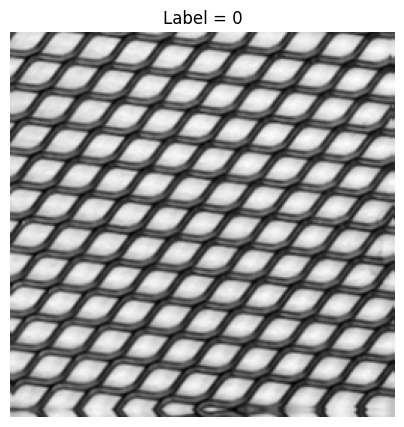

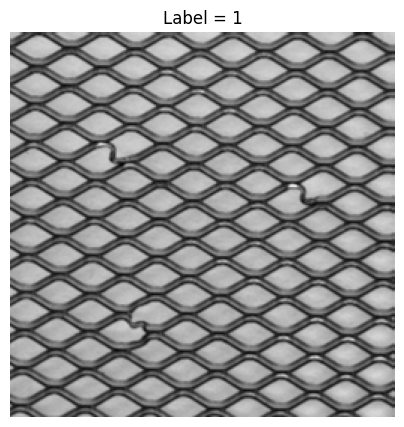

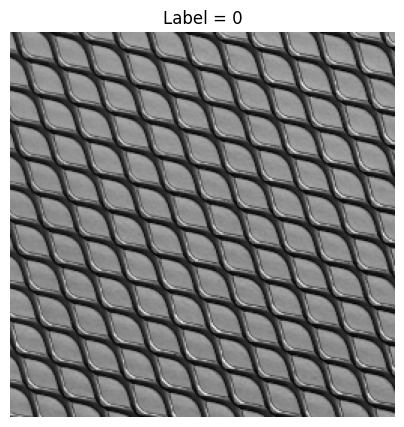

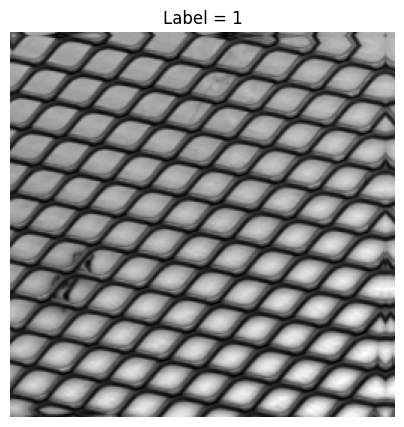

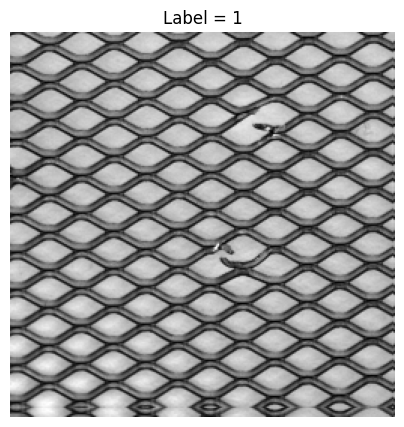

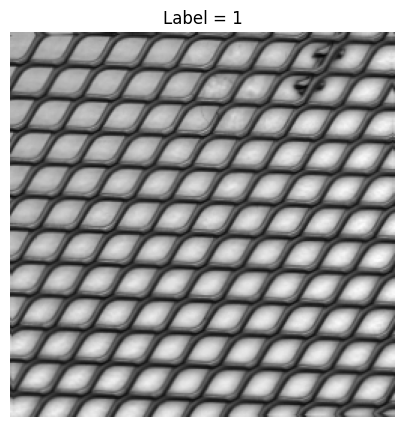

In [ ]:
##Affiche quelques images avec leur label pour voir si on a bien les bon label pour les bonnes images

for i in range(6):
    plt.figure(figsize=(5,5))

    plt.imshow(X_tr[i].squeeze(), cmap="gray")
    plt.title(f"Label = {y_tr[i]}")
    plt.axis("off")
    plt.show()


In [ ]:
print(np.unique(y_tr))
print(np.unique(y_val))

[0 1]
[0 1]


In [ ]:
# Entrée
inputs = Input(shape=(256, 256, 1), name="input_image")

# conv1
x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2, 2))(x)

#conv 2
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Bloc conv 3
x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Applatir pour les utiliser dans dense
x = GlobalAveragePooling2D()(x)

# Couche Dense 1
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
# Couche Dense 7
outputs = Dense(1, activation="sigmoid", name="output")(x)





# Modèle
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
## Après avoir renforcé le modèle, refais le overfit sur 64 images :
history_small = model.fit(
    X_tr[:64], y_tr[:64],
    epochs=10,
    batch_size=16,
    validation_data=(X_tr[:64], y_tr[:64]),
    verbose=1
)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.4729 - loss: 0.6931 - val_accuracy: 0.5312 - val_loss: 0.6927
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.5458 - loss: 0.6924 - val_accuracy: 0.5312 - val_loss: 0.6923
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5437 - loss: 0.6923 - val_accuracy: 0.5312 - val_loss: 0.6919
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5792 - loss: 0.6893 - val_accuracy: 0.5312 - val_loss: 0.6916
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5104 - loss: 0.6941 - val_accuracy: 0.5312 - val_loss: 0.6916
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5250 - loss: 0.6916 - val_accuracy: 0.5312 - val_loss: 0.6916
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5063 - loss: 0.6930 - val_accuracy: 0.5312 - val_loss: 0.6914
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4917 - loss: 0.6938 - val_accuracy: 0.5312 - val_loss: 0.6913
Epoch 9/

In [ ]:
## Ajout de callbak pour stopper le modele si la val_loss stagne
early_stopping= EarlyStopping(patience=5, min_delta=0.001,verbose=1, mode='min',monitor= "val_loss")

reduceLR= ReduceLROnPlateau( monitor= "val_loss",patience=3, min_delta=0.01, factor=0.1, mode='min',verbose=1,cooldown=4)


In [ ]:
#### entrainnement du modele  en utilisant epochs=10, batch_size=32 et on laisse 20% pour les données de validation:

history = model.fit(X_tr, y_tr, epochs=10, batch_size=32,  validation_data=( X_val, y_val) ,callbacks=[reduceLR, early_stopping])



Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 242s 5s/step - accuracy: 0.5122 - loss: 0.6938 - val_accuracy: 0.5327 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.5130 - loss: 0.6955 - val_accuracy: 0.5327 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.5348 - loss: 0.6922 - val_accuracy: 0.5327 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5545 - loss: 0.6802
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
50/50 ━━━━━━━━━━━━━━━━━━━━ 340s 6s/step - accuracy: 0.5540 - loss: 0.6802 - val_accuracy: 0.5327 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 273s 5s/step - accuracy: 0.5449 - loss: 0.6896 - val_accuracy: 0.5327 - val_loss: 0.6843 - learning_rate: 1.0000e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 226s 4s/step - accuracy: 0.5342 - loss: 0.6838 - val_a

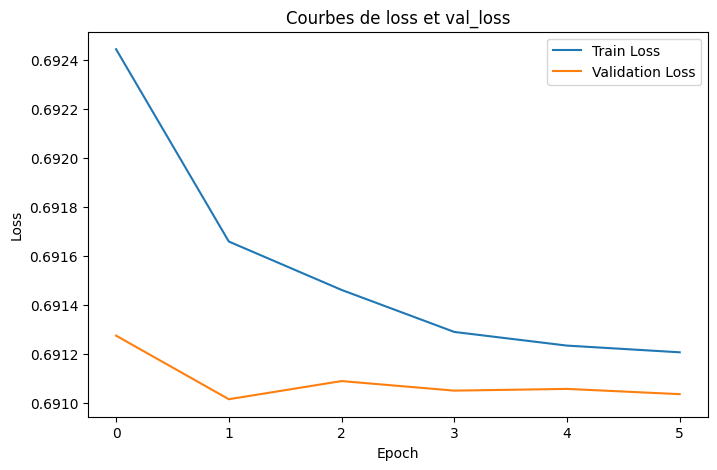

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')


plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
##faire les prediction avec X_test:
y_proba = model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.5).astype(int)       # classes 0/1

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

Accuracy : 0.32
Precision: 0.00
Recall:  0.00
F1-score: 0.00
Confusion Matrix:
 [[126   0]
 [270   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
##faire les prediction avec X_test:
y_proba = model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.65).astype(int)       # classes 0/1

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

###### Interpretability GRAD_Cam:

In [ ]:
def grad_cam(img, model, layer_name):
    # 1) Récupérer la couche conv ciblée
    conv_layer = model.get_layer(layer_name)

    # 2) Modèle intermédiaire: sortie conv + sortie finale
    grad_model = Model(model.inputs, [conv_layer.output, model.output])

    # 3) Ajouter dimension batch
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    img = tf.expand_dims(img, axis=0)  # (1,H,W,C)

    # 4) GradientTape
    with tf.GradientTape() as tape:
        conv_outputs, pred = grad_model(img)
        # pred shape: (1,1) -> proba classe 1
        loss = pred[:, 0]  # score pour la classe "1"

    # 5) Gradients
    grads = tape.gradient(loss, conv_outputs)  # (1,h,w,channels)

    # 6) Pondération par moyenne des gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (channels,)

    # 7) Heatmap
    conv_outputs = conv_outputs[0]  # (h,w,channels)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # (h,w)

    # 8) ReLU + normalisation
    heatmap = tf.maximum(heatmap, 0)
    denom = tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap / denom
    heatmap = heatmap.numpy()

    # 9) Resize heatmap à la taille de l’image
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis],
                                      (img.shape[1], img.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)

    # 10) Color + superposition
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]

    base = img[0].numpy()
    # si grayscale (H,W,1) -> convert to 3 channels pour l'affichage
    if base.shape[-1] == 1:
        base_rgb = np.repeat(base, 3, axis=-1)
    else:
        base_rgb = base

    superimposed = 0.6 * heatmap_colored + 0.4 * base_rgb
    superimposed = np.clip(superimposed, 0, 1)

    pred_proba = float(pred.numpy()[0, 0])
    pred_class = 1 if pred_proba >= 0.5 else 0

    return superimposed, heatmap_resized, pred_class, pred_proba


def show_grad_cam_cnn(images, model, max_images=4):
    conv_layer_names = [l.name for l in model.layers if isinstance(l, Conv2D)]
    n_imgs = min(images.shape[0], max_images)

    plt.figure(figsize=(4*n_imgs, 3*len(conv_layer_names)))

    for j, layer_name in enumerate(conv_layer_names):
        for i in range(n_imgs):
            idx = i + 1 + j * n_imgs
            plt.subplot(len(conv_layer_names), n_imgs, idx)

            cam_img, heat, pred_class, proba = grad_cam(images[i], model, layer_name)

            plt.title(f"{layer_name}\npred={pred_class} (p={proba:.2f})")
            plt.imshow(cam_img)
            plt.axis("off")

    plt.tight_layout()
    plt.show()


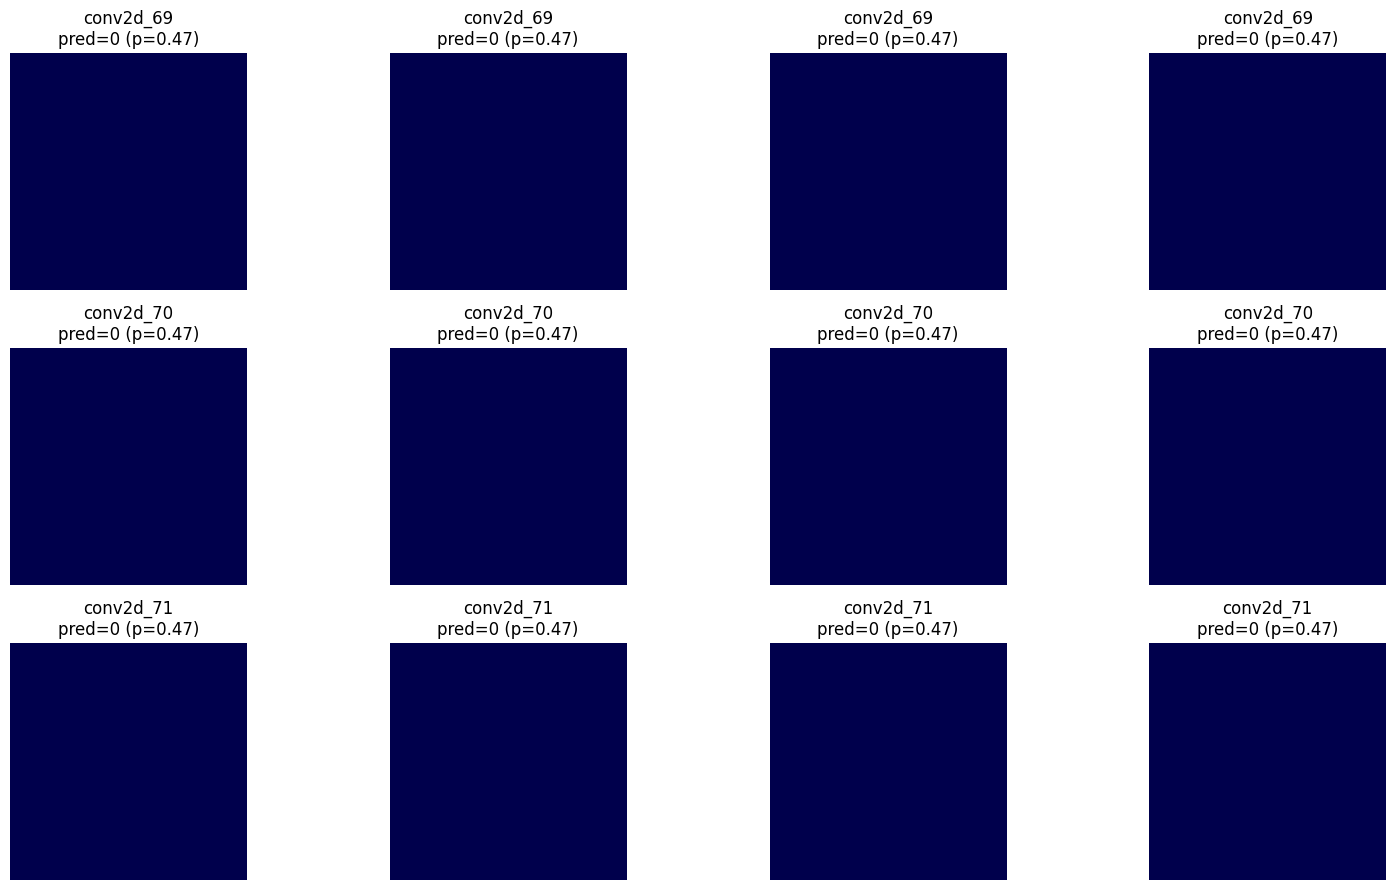

In [ ]:
show_grad_cam_cnn(X_val, model, max_images=4)

###### **`entrainnement avec les patches:`**

In [ ]:
def extract_patches(images, labels, patch_size=64, stride=64):
    X_patches = []
    y_patches = []

    for img, label in zip(images, labels):
        H, W, C = img.shape
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patch = img[y:y+patch_size, x:x+patch_size, :]
                X_patches.append(patch)
                y_patches.append(label)  # héritage du label image

    return np.array(X_patches), np.array(y_patches)


In [ ]:
X_tr_p, y_tr_p   = extract_patches(X_tr,  y_tr,  patch_size=64, stride=64)
X_val_p, y_val_p = extract_patches(X_val, y_val, patch_size=64, stride=64)

print(X_tr_p.shape, y_tr_p.shape)
print(X_val_p.shape, y_val_p.shape)

NameError: name 'extract_patches' is not defined

In [ ]:
inputs = Input(shape=(64, 64, 1), name="input_patch")

x = Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = GlobalAveragePooling2D()(x)

outputs = Dense(1, activation="sigmoid")(x)

model_patch = Model(inputs, outputs)
model_patch.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


In [ ]:
history = model.fit(
    X_tr_p, y_tr_p,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_p, y_val_p),
    callbacks=[reduceLR, early_stopping]
)


Epoch 1/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 214s 269ms/step - accuracy: 0.5300 - loss: 0.6915 - val_accuracy: 0.5327 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 2/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 259s 265ms/step - accuracy: 0.5251 - loss: 0.6920 - val_accuracy: 0.5327 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 3/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 242s 304ms/step - accuracy: 0.5324 - loss: 0.6912 - val_accuracy: 0.5327 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 4/10
 86/794 ━━━━━━━━━━━━━━━━━━━━ 2:54 247ms/step - accuracy: 0.5175 - loss: 0.6931

KeyboardInterrupt: 

###### non adapté

In [ ]:
def grad_cam(img, model, layer_name):
    # Récupérer la couche convolutive
    layer = model.get_layer(layer_name)

    # Créer un modèle qui génère les sorties de la couche convolutive et les prédictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Ajout d'une dimension de batch
    img = tf.expand_dims(img_prp, axis=0)

    # Calcul des gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        predicted_class = tf.argmax(predictions[0])  # Classe prédite
        loss = predictions[:, predicted_class]  # Perte pour la classe prédite

    # Gradients des scores par rapport aux sorties de la couche convolutive
    grads = tape.gradient(loss, conv_outputs)

    # Moyenne pondérée des gradients pour chaque canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Pondération des activations par les gradients calculés
    conv_outputs = conv_outputs[0]  # Supprimer la dimension batch
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalisation de la carte de chaleur
    heatmap = tf.maximum(heatmap, 0)  # Se concentrer uniquement sur les valeurs positives
    heatmap /= tf.math.reduce_max(heatmap)  # Normaliser entre 0 et 1
    heatmap = heatmap.numpy()  # Convertir en tableau numpy pour la visualisation

   # Redimensionner la carte de chaleur pour correspondre à la taille de l'image d'origine
    heatmap_resized = tf.img.resize(heatmap[..., np.newaxis], (img.shape[1], img.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1) # supprimer la dimension de taille 1 à la fin du tableau heatmap_resized

    # Colorier la carte de chaleur avec une palette (par exemple, "jet")
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3] # Récupérer les canaux R, G, B

    superimposed_image = heatmap_colored * 0.7 + img[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class

In [ ]:
def show_grad_cam_cnn(img, model):
    number_of_images = img.shape[0]
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    plt.figure(figsize=(16,16))

    for j, layer in enumerate(conv_layers):

        for i in range(number_of_images):

            subplot_index = i + 1 + j * number_of_images
            plt.subplot(len(conv_layers), number_of_images, subplot_index)

            # Obtenir l'image avec la carte de chaleur superposée
            grad_cam_image, predicted_class = grad_cam(images[i], model, layer)

            # Afficher l'image avec Grad-CAM
            plt.title(f'Grad-CAM {layer}')
            plt.imshow(grad_cam_image)
            plt.axis("off")

    plt.show()

show_grad_cam_cnn(img, model)

NameError: name 'img' is not defined